In [2]:
import os
import pandas as pd

## Get the data

In [3]:
files_A = ["0", "3", "10", "13", "14", "17", "22", "24", "25", "26", "38",
           "40", "42", "45", "51", "68", "69", "71", "72", "73", "84", "92"]
path_base_A = os.path.join("data", "Wind Farm A", "datasets")

files_B = ["2", "7", "19", "21", "23", "27", "34", "52", "53", "74", "77",
           "82", "83", "86", "87"]
path_base_B = os.path.join("data", "Wind Farm B", "datasets")

In [4]:
dataframes_A = []
dataframes_B = []

for f_A in files_A:
    path = os.path.join(path_base_A, f_A + ".csv")
    df = pd.read_csv(path, delimiter=";")
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    dataframes_A.append(df)

for f_B in files_B:
    path = os.path.join(path_base_B, f_B + ".csv")
    df = pd.read_csv(path, delimiter=";")
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    dataframes_B.append(df)


<h1> Plot missing values </h1>

In [5]:
import matplotlib.pyplot as plt

In [8]:
missing_values = []
names = []

for i in range(len(dataframes_A)):
    missing = dataframes_A[i].isnull().sum().sum()
    missing_values.append(missing)
    names.append(files_A[i] + "A")

for i in range(len(dataframes_B)):
    missing = dataframes_B[i].isnull().sum().sum()
    missing_values.append(missing)
    names.append(files_B[i] + "B")



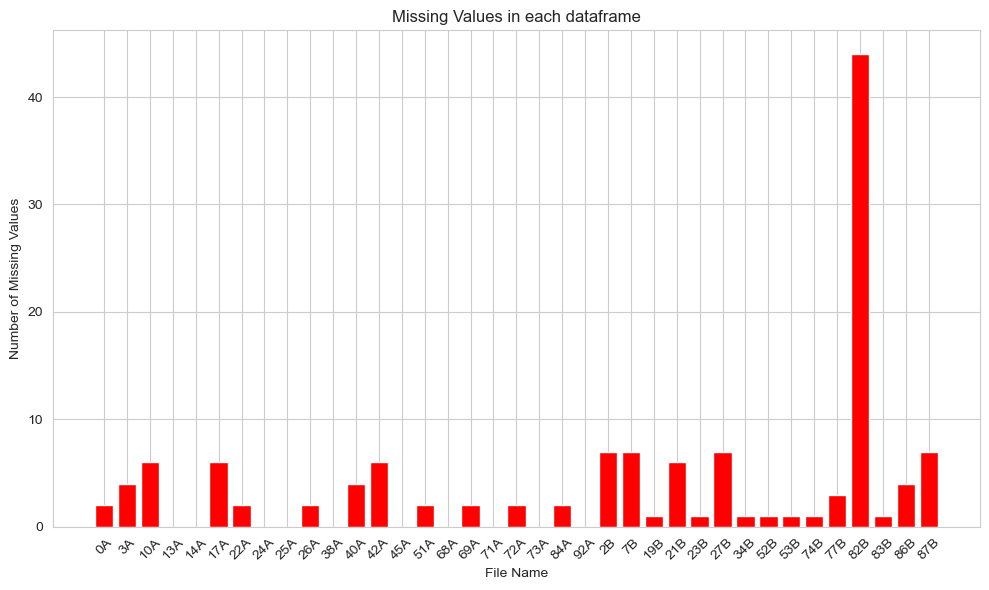

In [60]:
plt.figure(figsize=(10, 6))
plt.bar(names, missing_values, color='red')
plt.xlabel('File Name')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values in each dataframe')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1> Test to train </h1>

In [64]:
names = []
percentages = []


for i in range(len(dataframes_A)):
    train_count = (dataframes_A[i]["train_test"] == "train").sum()
    test_count = (dataframes_A[i]["train_test"] == "prediction").sum()
    percentages.append(100.0 * test_count / (train_count + test_count))


    names.append(files_A[i] + "A")

for i in range(len(dataframes_B)):
    train_count = (dataframes_B[i]["train_test"] == "train").sum()
    test_count = (dataframes_B[i]["train_test"] == "prediction").sum()
    percentages.append(100.0 * test_count / (train_count + test_count))


    names.append(files_B[i] + "B")


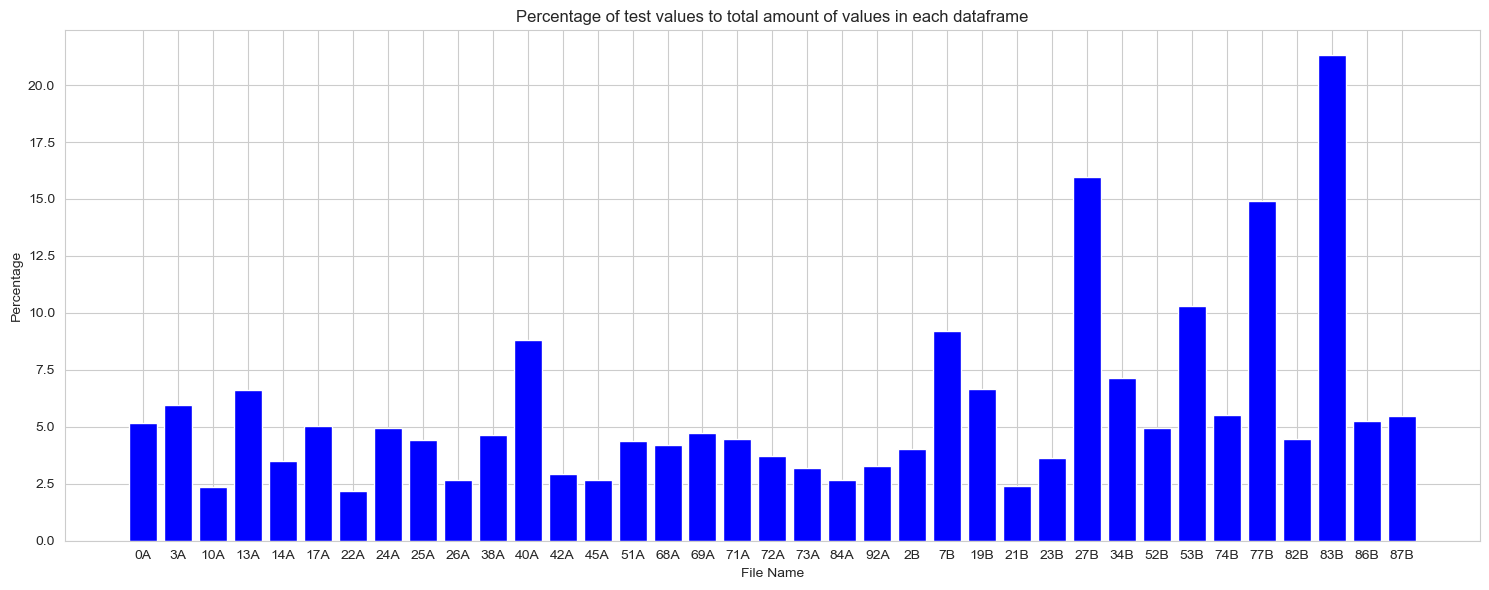

In [68]:
plt.figure(figsize=(15, 6))
plt.bar(names, percentages, color='blue')
plt.xlabel('File Name')
plt.ylabel('Percentage')
plt.title('Percentage of test values to total amount of values in each dataframe')
plt.tight_layout()
plt.show()

<h1> Windspeed power correlation </h1>

In [14]:
import seaborn as sns

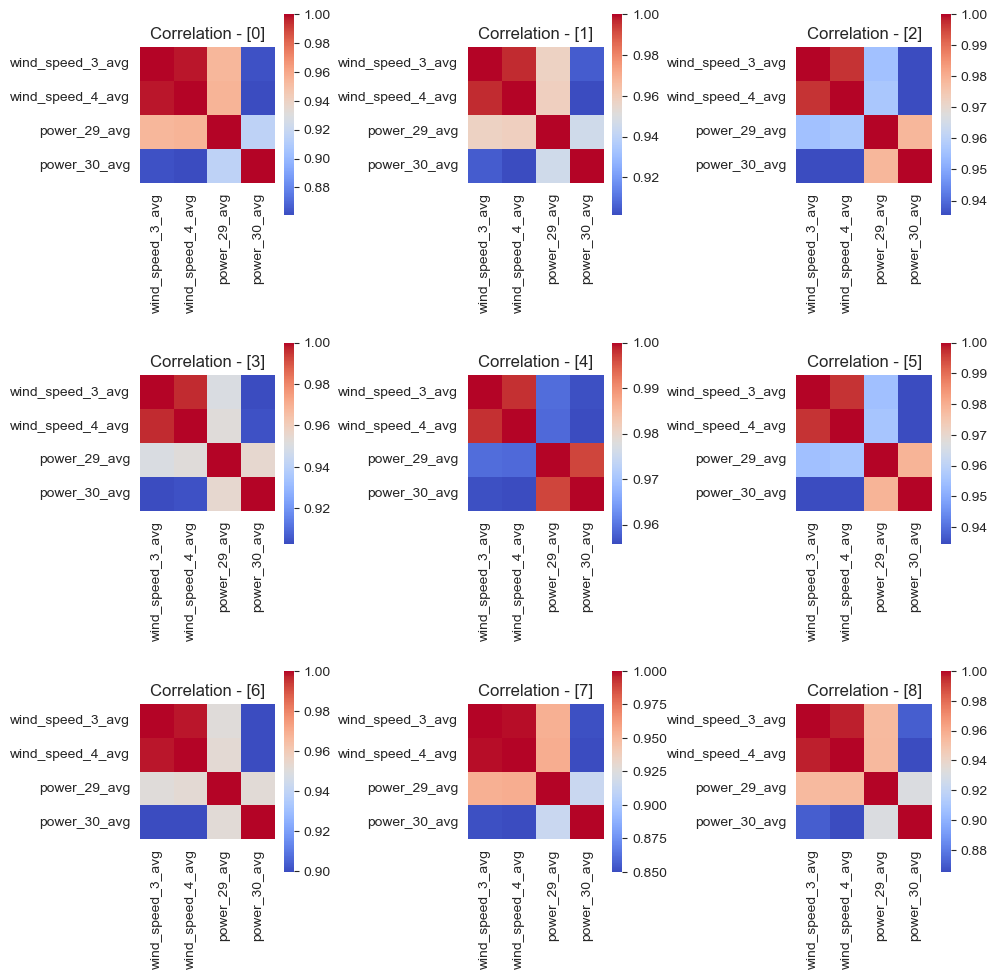

In [58]:
indices = [0, 1, 2, 3, 4, 5, 6, 7, 8]
which_list = dataframes_A

plot_size = 3

fig, axes = plt.subplots(plot_size, plot_size, figsize=(10, 10))  # 2x2 grid

for i, idx in enumerate(indices):
    df = which_list[idx]

    selected_columns = [col for col in df.columns if ("wind_speed" in col or "power" in col) and "avg" in col and "reactive" not in col]
    df_selected = df[selected_columns]

    correlation_matrix = df_selected.corr()

    row, col = divmod(i, plot_size)

    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', square=True, ax=axes[row, col])

    axes[row, col].set_title(f'Correlation - [{idx}]')

plt.tight_layout()
plt.show()

<h1> Clusters for wind speed power </h1>

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [91]:
selected_columns = [col for col in dataframes_A[4].columns if ("wind_speed" in col or "power" in col) and "avg" in col and "reactive" not in col]
df_selected = dataframes_A[4][selected_columns]

In [92]:
df_selected = df_selected.dropna()

In [85]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

In [86]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
df_selected['cluster'] = kmeans.fit_predict(df_scaled)

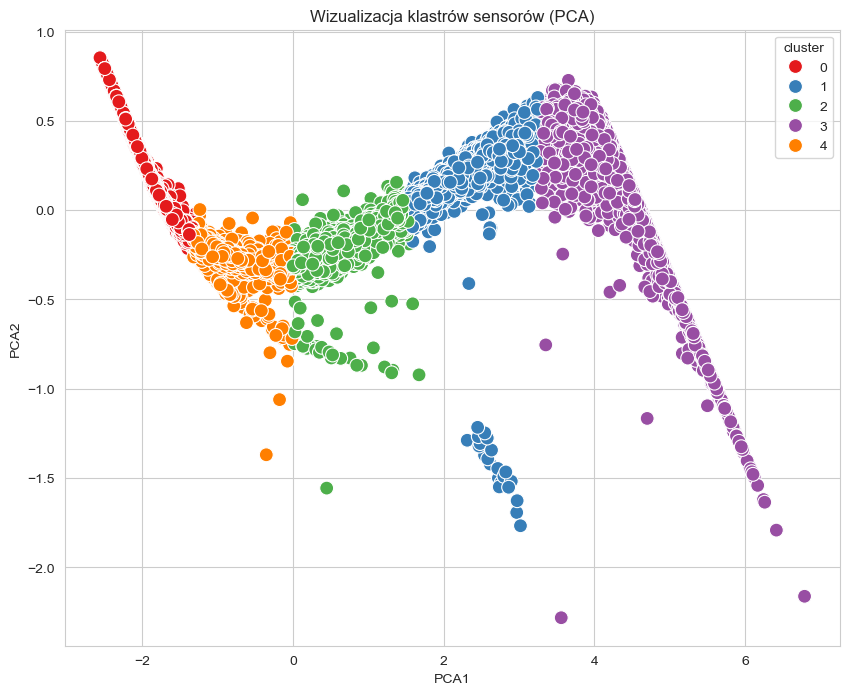

In [87]:

pca = PCA(n_components=2)
sensor_df_2D = pca.fit_transform(df_scaled)

df_selected['PCA1'] = sensor_df_2D[:, 0]
df_selected['PCA2'] = sensor_df_2D[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df_selected, palette='Set1', s=100)
plt.title('Wizualizacja klastrów sensorów (PCA)')
plt.show()